In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
data = pd.read_csv('/content/Cardataset.csv')

data['drag_coefficient'] = data['drag_coefficient'].str.replace(r' \(est\)', '', regex=True).astype(float)
data['frontal_area_m2'] = data['frontal_area_m2'].str.replace(r' \(est\)', '', regex=True).astype(float)

X = data.drop(columns=['Model', 'est_km_per_l'])
y = data['est_km_per_l']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

Feature Importance Listed
             Car Spec    Weight
10         env_temp_C  0.000000
9           fuel_type  0.001393
2       mag_weight_kg  0.019016
1       mag_size_inch  0.024419
3       tire_width_mm  0.024934
4   tire_pressure_psi  0.045345
6     frontal_area_m2  0.070460
7          horsepower  0.088330
5    drag_coefficient  0.092250
8     displacement_cc  0.136893
0       total_mass_kg  0.496961


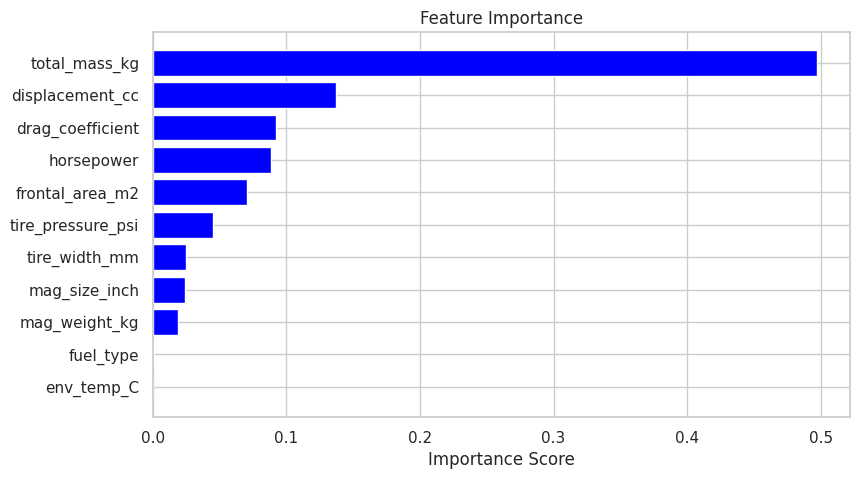

In [35]:
feat_scores = rf.feature_importances_
importance_table = pd.DataFrame({
    'Car Spec': X.columns,
    'Weight': feat_scores
})

importance_table = importance_table.sort_values(by='Weight', ascending=True)
print("Feature Importance Listed")
print(importance_table)
plt.figure(figsize=(9, 5))
plt.barh(importance_table['Car Spec'], importance_table['Weight'], color='blue')
plt.title('Feature Importance')
plt.xlabel('Importance Score')

plt.show()

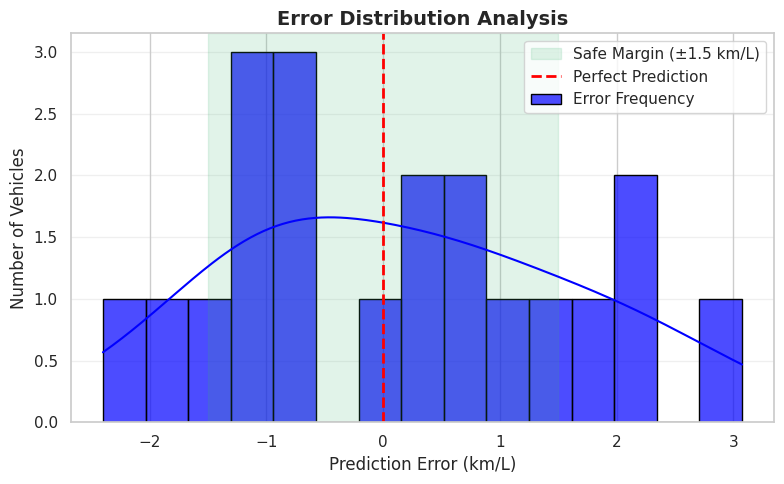

In [67]:
rf_error = y_test - y_pred_rf

plt.figure(figsize=(8, 5))

sns.histplot(rf_error, bins=15, kde=True, color='blue',
             edgecolor='black', alpha=0.7, label='Error Frequency')
plt.axvspan(-1.5, 1.5, color='mediumseagreen', alpha=0.15, label='Safe Margin (±1.5 km/L)')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.title('Error Distribution Analysis', fontsize=14, weight='bold')
plt.xlabel('Prediction Error (km/L)', fontsize=12)
plt.ylabel('Number of Vehicles', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

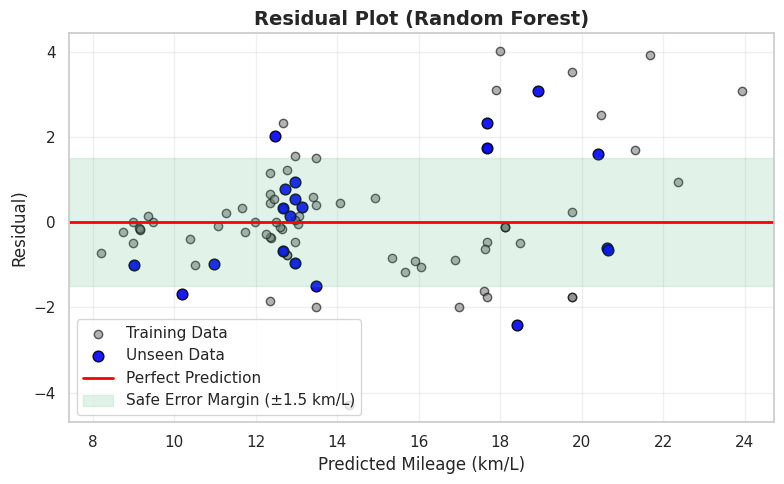

In [69]:
y_pred_train = rf.predict(X_train)
train_error = y_train - y_pred_train

plt.figure(figsize=(8, 5))

plt.scatter(y_pred_train, train_error, color='grey', alpha=0.6, edgecolor='black', label='Training Data')
plt.scatter(y_pred_rf, rf_error, color='blue', alpha=0.9, edgecolor='black', s=60, label='Unseen Data')
plt.axhline(y=0, color='red', linestyle='-', linewidth=2, label='Perfect Prediction')
plt.axhspan(-1.5, 1.5, color='mediumseagreen', alpha=0.15, label='Safe Error Margin (±1.5 km/L)')
plt.title('Residual Plot (Random Forest)', fontsize=14, weight='bold')
plt.xlabel('Predicted Mileage (km/L)', fontsize=12)
plt.ylabel('Residual)', fontsize=12)
plt.legend(loc='lower left')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

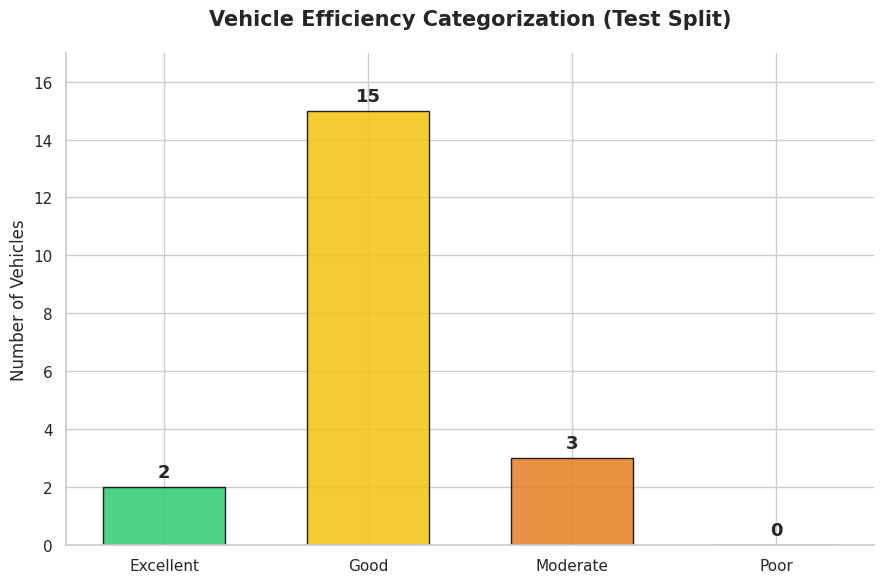

In [83]:
results = X_test.copy()
results['Predicted_km_L'] = y_pred_rf

results['FEI_Score'] = (results['Predicted_km_L'] * results['total_mass_kg']) / 1000
def get_status(score):
    if score >= 25: return "Excellent"
    elif score >= 18: return "Good"
    elif score >= 12: return "Moderate"
    else: return "Poor"

results['Status'] = results['FEI_Score'].apply(get_status)
status_order = ["Excellent", "Good", "Moderate", "Poor"]
counts = results['Status'].value_counts().reindex(status_order).fillna(0)
plt.figure(figsize=(9, 6))
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
bars = plt.bar(counts.index, counts.values, color=colors, edgecolor='black', alpha=0.85, width=0.6)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.2,
             int(yval), ha='center', va='bottom', weight='bold', fontsize=13)
plt.title('Vehicle Efficiency Categorization (Test Split)', fontsize=15, weight='bold', pad=20)
plt.ylabel('Number of Vehicles', fontsize=12)
plt.ylim(0, max(counts.values) + 2)
sns.despine()

plt.tight_layout()
plt.show()

In [109]:
car = X_test.iloc[0:1].copy()
car['total_mass_kg']     = 890   # Weight of the car
car['mag_size_inch']     = 25     # Wheel rim size
car['mag_weight_kg']     = 16.0    # Wheel rim weight
car['tire_width_mm']     = 500    # Tire width
car['tire_pressure_psi'] = 32     # Tire pressure
car['drag_coefficient']  = 0.29   # Aerodynamics
car['frontal_area_m2']   = 2.0    # Aerodynamics
car['horsepower']        = 155    # Engine power
car['displacement_cc']   = 1600   # Engine size
car['fuel_type']         = 2      # 1=Diesel, 2=Gasoline
car['env_temp_C']        = 30     # Environment temperature

predicted_kml = rf.predict(car)[0]
fei_score = (predicted_kml * car['total_mass_kg'].values[0]) / 1000

print("=" * 55)
print("Car Mileage Predictor")
print("=" * 55)
print(f"Vehicle Specs : {car['total_mass_kg'].values[0]} kg | {car['horsepower'].values[0]} HP | {car['displacement_cc'].values[0]} CC")
print(f"AI Prediction : {predicted_kml:.2f} km/L")
print(f"FEI Score     : {fei_score:.1f}")
print(f"Status Tier   : {get_status(fei_score).replace('\n', ' ')}")
print("=" * 55)

Car Mileage Predictor
Vehicle Specs : 890 kg | 155 HP | 1600 CC
AI Prediction : 19.23 km/L
FEI Score     : 17.1
Status Tier   : Moderate


In [122]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)
print("="*40)
print("Model Evaluation Metrics")
print("="*40)
print(f"Mean Absolute Error (MAE) : {mae:.2f} km/L")
print(f"Root Mean Sq. Error (RMSE): {rmse:.2f} km/L")
print(f"R-squared (R2) Score      : {r2:.3f} = {r2*100:.1f}%")
print("="*40)

Model Evaluation Metrics
Mean Absolute Error (MAE) : 1.22 km/L
Root Mean Sq. Error (RMSE): 1.44 km/L
R-squared (R2) Score      : 0.882 = 88.2%


In [130]:
from sklearn.model_selection import cross_val_score
cv_scores = -cross_val_score(rf, X, y, cv=5, scoring='neg_mean_absolute_error')

print("="*50)
print("Cross Validation")
print("="*50)
print(f"Fold 1 Error : {cv_scores[0]:.2f} km/L")
print(f"Fold 2 Error : {cv_scores[1]:.2f} km/L")
print(f"Fold 3 Error : {cv_scores[2]:.2f} km/L")
print(f"Fold 4 Error : {cv_scores[3]:.2f} km/L")
print(f"Fold 5 Error : {cv_scores[4]:.2f} km/L")
print("-" * 50)
print(f"Average Error: {np.mean(cv_scores):.2f} km/L")
print(f"STD Deviation: ± {np.std(cv_scores):.2f} km/L")
print("="*50)

Cross Validation
Fold 1 Error : 1.27 km/L
Fold 2 Error : 1.06 km/L
Fold 3 Error : 2.64 km/L
Fold 4 Error : 3.08 km/L
Fold 5 Error : 1.88 km/L
--------------------------------------------------
Average Error: 1.99 km/L
STD Deviation: ± 0.77 km/L
